# for Cadets and Theia
- 不要想着代码适配所有数据集，只要适配自己的需求就可以了
  - Cadets和Theia选取案例不涉及IPC，不考虑所有IPC通信。理论上可以说，但实际上不考虑。
  - 当前数据集在如何将Socket Server和Client对应起来描述一个正常的通信流程也存在问题。
- 先设计一个数据提取方法能够完整地把攻击活动提取出来
  - 在提取地过程中发现问题 --- 解决问题

# 日志解析：舍弃不关心的事件和实体，从关心的日志中提取需要的内容

- 需要考虑Connect和Accept操作（只考虑与Network相关的事件），在这样能够体现出端口扫描行为   0915

In [223]:
import os
import pickle
from tqdm import tqdm
import networkx as nx

CentralDIct = {
    # 'ta1-cadets-e3-official.json.2':'F77E454D-CA07-6B5D-87CA-9EFDCD6BA3ED',
               'ta1-cadets-e3-official-2.json':'5026C48F-56BA-3E5B-BA56-DD382B3EC82B',
            #    'ta1-cadets-e3-official-2.json.1':'E5A15412-68E0-FD54-A068-DD6114FD9040',
            #   'ta1-theia-e3-official-6r.json':'0100D00F-5EC5-0600-0000-0000697C471C',
            #   'ta1-theia-e3-official-6r.json':'0100D00F-44C5-0600-0000-00006E15B00E',
            #   'ta1-theia-e3-official-6r.json.8':'0100D00F-B700-2800-0000-00002BDE0334',
            #   'ta1-trace-e3-official-1.json.3':'17498F61-1D2A-DEB2-F6E5-EB447ABF4A60',
                # 'ta1-trace-e3-official-1.json.3':'93E0C854-95A4-FE1B-245B-6E217A409764'
              
              }

for key in CentralDIct:
    if 'cadets' in key:
        SubSet = 'Cadets'
    elif 'theia' in key:
        SubSet = 'Theia'
    elif 'trace' in key:
        SubSet = 'Trace'
    TargetScenario = key
    TargetNode = CentralDIct[key]


In [224]:
# import pickle
# SubSet =  'Cadets'                    # DARPATC下子数据集
# TargetScenario =  'ta1-cadets-e3-official.json.2'           # 子数据集下的数据文件
# # AttckNode = 'C31_KeyResult'             # 攻击场景命名
# TargetNode='F77E454D-CA07-6B5D-87CA-9EFDCD6BA3ED'  # 攻击场景下恶意节点
# with open("D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\\Ablation_Exp\\WithoutDataOptimize\\{x}\\Graph_{y}.data".format(x=SubSet,y=TargetScenario),'rb') as f:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\DARPATC\\{x}\\1.2Test\\ProGraph\\Graph_{y}.data".format(x=SubSet,y=TargetScenario),'rb') as f:
    G = pickle.load(f)

# G.remove_node('0100D00F-C81A-2E00-0000-0000E02BC029')
# G.remove_node('0100D00F-261E-2E00-0000-0000DCC3B50B')



In [225]:
# # AAA = '84E212DB-2441-BDA0-099F-5DCEC3D4CCC3'
# Firefox = {}
# Thunder = {}
# AAA = '2ABA72EA-BA2D-2836-F1DA-0A0771C805D8'
# print(AAA,G.nodes[AAA])
# for node in G.predecessors(AAA):
    
#     # if G.nodes[node]['type'] == 'SUBJECT_PROCESS':
#         # print(node,G.nodes[node])
#     for value in G.get_edge_data(node,AAA).values():
#         # if value['Sequence']>=914531:
#         print(node,G.nodes[node],value)

#         if G.nodes[node]['Cmdline'] == 'firefox':
#             if node not in Firefox:
#                 Firefox[node] = value['Sequence']

#         if G.nodes[node]['Cmdline'] == '/usr/lib/thunderbird/thunderbird':
#             if node not in Thunder:
#                 Thunder[node] = value['Sequence']
# print('_______')

# for node in G.successors(AAA):
    
#     # if G.nodes[node]['type'] == 'SUBJECT_PROCESS':
#         # print(node,G.nodes[node])
#     for value in G.get_edge_data(AAA,node).values():
#         # if value['Sequence']>=914531:
#         print(G.nodes[node],node,value)

#         if G.nodes[node]['Cmdline'] == 'firefox':
#             if node not in Firefox:
#                 Firefox[node] = value['Sequence']

#         if G.nodes[node]['Cmdline'] == '/usr/lib/thunderbird/thunderbird':
#             if node not in Thunder:
#                 Thunder[node] = value['Sequence']
# print('_______')


In [226]:
# '终端'概念再Linux中是以文件形式体现的:/dev/tty，代表计算机的输入的输出。
# 参考：<https://cloud.tencent.com/developer/article/1527544>,<https://www.bilibili.com/video/BV1FV411Z7y5/?spm_id_from=333.337.search-card.all.click&vd_source=bfd15b38f2dcd971633f7ff9e3f10ea1>
# 在同一个Bash下，我们在终端进行的输入和输出是不相互影响的,即独立指令之间不会因为终端存在信息的流动。对此需要对该文件作特殊处理。
# Bash:<https://zhuanlan.zhihu.com/p/328045475>
def NoNeedNode(Graph,node):  # 在主干信息流内需要排除的文件
    Result = False
    FileType = ['FILE_OBJECT_BLOCK','FILE_OBJECT_FILE','FILE_OBJECT_DIR']
    # MatchChar= ['/dev/tty','bash_history','/dev/console','/dev/null','/home/admin/.mozilla/firefox','/home/admin/.cache/mozilla/firefox','/var/run/sudo/ts/admin','/admin/.thunderbird']  # 即这些节点不能代表信息流的传递关系，对这些文件的写入和读出都不被考虑。
    MatchChar= ['/dev/tty','/dev/console','/dev/null','/var/run/sudo/ts/admin']  # 即这些节点不能代表信息流的传递关系，对这些文件的写入和读出都不被考虑。
    # MatchChar = []
    # MatchChar= ['bash_history','/dev/null','/var/run/sudo/ts/admin']  # 即这些节点不能代表信息流的传递关系，对这些文件的写入和读出都不被考虑。


    if Graph.nodes[node]['type'] in FileType and Graph.nodes[node]['path']:
        if any(MChar in Graph.nodes[node]['path'] for MChar in MatchChar):
            Result = True
    if Graph.nodes[node]['type'] == 'NetFlowObject' and G.nodes[node]['remoteAddress'] == 'NA':
        Result = True
    return Result

def DontAddNode(Graph,node): # 如果不在主干信息流内，不需要额外添加的文件
    Result = False
    FileType = ['FILE_OBJECT_BLOCK','FILE_OBJECT_FILE','FILE_OBJECT_DIR']
    MatchChar= ['/dev/shm','/run/shm','/home/admin/.mozilla/firefox','/home/admin/.cache/mozilla/firefox','/var/run/sudo/ts/admin','/.cache/thunderbird/','/etc/fonts','/admin/.thunderbird']  # 即这些节点不能代表信息流的传递关系，对这些文件的写入和读出都不被考虑。
    if Graph.nodes[node]['type'] in FileType and Graph.nodes[node]['path']:
        if any(MChar in Graph.nodes[node]['path'] for MChar in MatchChar):
            Result = True
    if Graph.nodes[node]['type'] == 'NetFlowObject' and G.nodes[node]['remoteAddress'] == 'NA':
        Result = True
    return Result

# for node in SubGraph:
#     if SubGraph.nodes[node]['type'] in FileType and SubGraph.nodes[node]['path']:
#         for MChar in MatchChar:
#             if MChar in SubGraph.nodes[node]['path']:
#                 NoNeedNode.append(node)
#                 break
# print(NoNeedNode)
# # SearchGraph.remove_nodes_from(NoNeedNode) # tty不参与网络活动，只会作为内部节点出现。我们认为每次对tty的读写是独立的操作，不会因为不同进程对tty文件的读写而导致信息的交互。
# SubGraph.remove_nodes_from(NoNeedNode) # SubGraph中也移除此类不关心节点

# 序列提取

- 0.错误信息流向纠正（删除干扰节点）
- 1.依据可疑节点确定信息源和信息终点的暴露节点
- 2.依据确定的源和终点还原信息流中关键节点
- 3.长链进程缩减
- 4.依据关键节点补充细节信息（如额外的信息流）

In [227]:
import copy
import time

NodeCount = 0
EdgeCount = 0

GlobalNoNeedNode = {} #key:node value:Label

def  EdgeNodes(G,TargetNode):
    result = 0
    if  G.nodes[TargetNode]['type'] == 'NetFlowObject' and G.nodes[TargetNode]['remoteAddress'] != 'NA':# NetFlowObject为边界节点，必须有向外的信息流才算作暴露节点
        # print(3)
        result = 3
        return result
    elif len(list( G.successors(TargetNode))) == 0 or len(list( G.predecessors(TargetNode))) == 0:# 无出边节点为边界节点  流终点
        # print(2)
        result = 1
        return result
    return result

def AddExp(Res,node):
    if node not in Res:
        Res.append(node)
    else:
        Res.remove(node)
        Res.append(node)
    return Res
    
def GetSeqInfo(G,node1,node2):
    global EdgeCount
    Edges = G.get_edge_data(node1,node2)
    EdgeCount += len(Edges)
    Seqs = [edge['Sequence'] for edge in Edges.values() if edge['type'] != 'EVENT_UNLINK']
    return Seqs

def GetNext(Next,G,node0,node1): # node0:Nownode node1:Nextnode
    # print(Next)
    global EdgeCount
    Edges = G.get_edge_data(node0,node1)
    EdgeCount += len(Edges)
    SeqList = [value['Sequence'] for value in Edges.values() if value['Sequence'] >= Next and value['type'] != 'EVENT_UNLINK']
    if SeqList:
        return min(SeqList) # 大于当前时序的最小值
    return None

def GetPre(Pre,G,node0,node1): # node0:Prenode node1:Nownode
    global EdgeCount
    Edges = G.get_edge_data(node0,node1)
    EdgeCount += len(Edges)
    SeqList = [value['Sequence'] for value in Edges.values() if value['Sequence'] <= Pre and value['type'] != 'EVENT_UNLINK']
    if SeqList:
        return max(SeqList) # 小于当前时序的最大值
    return None

def Find_Related_Network(G,Node): # 默认Nodelist相互连通,若不互相联通则独立处理
    global GlobalNoNeedNode,NodeCount
    starttime = time.time()
    # global sub_nodes, node_set, G_subgraph, G

    # 保存遍历过的节点（除NoNeedNode和EdgeNode）
    oldForNode = set()
    oldBackNode = set()

# 使用列表保存时序
    ForExpNode = []
    BackExpNode = []

    # 保存互联网节点
    ForNetNode = set()
    BackNetNode =set()
    
    # 保存遍历路径中的时序信息
    ForNodeSeq = {} # key:node value:sequence
    BackNodeSeq = {}
   
    #保存节点的合法前序和后继
    ForwardNodes = set() # 前驱结果节点
    BackwardNodes = set() # 后继结果节点

    # CandidateNode=set(Nodelist) # 候选节点

    # 准备初始节点的合法前序和后继
    ForwardPool = list(G.successors(Node))
    oldForNode.add(Node) # 保存前向遍历过的节点
    for node in ForwardPool:
        # NodeNumber += 1
        NodeCount += 1
        temp = GetSeqInfo(G,Node,node) # 注意边方向
        # EdgeNumber += len(G.get_edge_data(Node,node))
        if temp:
            Result = EdgeNodes(G,node)
            NoNeedLabel = None
            if node in GlobalNoNeedNode:
                NoNeedLabel = GlobalNoNeedNode[node]
            else:
                GlobalNoNeedNode[node] = NoNeedNode(G,node)
                NoNeedLabel = GlobalNoNeedNode[node]
            if Result == 0 and NoNeedLabel==False:
                ForNodeSeq[node] = min(temp)
                ForwardNodes.add(node) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                # oldForNode.add(node)
            elif Result==3 and G.nodes[node]['remoteAddress'] != 'NA': # 记录互联网节点和暴露节点，这里的暴露节点是符合时序逻辑的
                ForNetNode.add(node)
                ForExpNode = AddExp(ForExpNode,Node)
                # 网络节点可能与数个暴露节点相关，故可能会产生多次遍历。故不加入oldnodes
                
    
    BackwardPool = list(G.predecessors(Node))
    oldBackNode.add(Node) # 保存后向遍历过的节点
    for node in BackwardPool:
        # NodeNumber += 1
        NodeCount += 1
        temp = GetSeqInfo(G,node,Node) # 注意边方向
        # EdgeNumber += len(G.get_edge_data(node,Node))
        if temp:
            Result = EdgeNodes(G,node)
            NoNeedLabel = None
            if node in GlobalNoNeedNode:
                NoNeedLabel = GlobalNoNeedNode[node]
            else:
                GlobalNoNeedNode[node] = NoNeedNode(G,node)
                NoNeedLabel = GlobalNoNeedNode[node]
            if Result == 0 and NoNeedLabel==False:
                BackNodeSeq[node] = max(temp)
                BackwardNodes.add(node) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                # oldBackNode.add(node)
            elif Result==3 and G.nodes[node]['remoteAddress'] != 'NA':
                BackNetNode.add(node)
                BackExpNode = AddExp(BackExpNode,Node)
           
                
        
    # BackwardNodes = list(G.predecessors(Node))
    while True:
        
        # 取差集
        NowForWard = [node for node in ForwardNodes if node not in oldForNode]
        NowBackWard = [node for node in BackwardNodes if node not in oldBackNode]
        # print(NowForWard,NowBackWard)
        ForwardNodes = set()
        BackwardNodes = set()

        if len(NowForWard) + len(NowBackWard) == 0:
            break

        # Forward  排除Unlink只对ForwardTracking有效
        for node in NowForWard:	
            oldForNode.add(node) # 保存所有前向遍历过的节点

                
            ForwardPool = list(G.successors(node)) # or neighbors # 返回迭代器，用过就归零。互联网节点只会在该集合中出现

            # 排除UNLINK的影响，不承认Unlink带来的信息流
            for nextnode in ForwardPool:
                # NodeNumber += 1
                NodeCount += 1
                temp = GetNext(ForNodeSeq[node],G,node,nextnode)
                if temp:
                    Result = EdgeNodes(G,nextnode)
                    NoNeedLabel = None
                    if nextnode in GlobalNoNeedNode:
                        NoNeedLabel = GlobalNoNeedNode[nextnode]
                    else:
                        GlobalNoNeedNode[nextnode] = NoNeedNode(G,nextnode)
                        NoNeedLabel = GlobalNoNeedNode[nextnode]
                    if Result == 0 and NoNeedLabel==False:
                        if nextnode not in ForNodeSeq:
                            ForNodeSeq[nextnode] = temp
                        else:  # 一个节点可能同时是多个节点的前序/后继，故有此处理
                            ForNodeSeq[nextnode] = min(temp,ForNodeSeq[nextnode])
                        ForwardNodes.add(nextnode) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                    elif Result==3 and G.nodes[nextnode]['remoteAddress'] != 'NA':
                        ForNetNode.add(nextnode)
                        ForExpNode = AddExp(ForExpNode,node)
                        

        for node in NowBackWard:	
            oldBackNode.add(node) # 保存后向遍历过的节点,这些节点都是非边缘、非网络、非无效信息流的节点
           
            BackwardPool = list(G.predecessors(node))

            for prenode in BackwardPool:
                # NodeNumber += 1
                NodeCount += 1
                temp = GetPre(BackNodeSeq[node],G,prenode,node)
                if temp:
                    Result = EdgeNodes(G,prenode)
                    NoNeedLabel = None
                    if prenode in GlobalNoNeedNode:
                        NoNeedLabel = GlobalNoNeedNode[prenode]
                    else:
                        GlobalNoNeedNode[prenode] = NoNeedNode(G,prenode)
                        NoNeedLabel = GlobalNoNeedNode[prenode]
                    if Result == 0 and NoNeedLabel==False:
                        if prenode not in BackNodeSeq:
                            BackNodeSeq[prenode] = temp
                        else:
                            BackNodeSeq[prenode] = max(temp,BackNodeSeq[prenode])
                        BackwardNodes.add(prenode)
                    elif Result==3 and G.nodes[prenode]['remoteAddress'] != 'NA':
                        BackNetNode.add(prenode)
                        BackExpNode = AddExp(BackExpNode,node)
    
    print('遍历边数-暴露节点确定：',EdgeCount)
    print('遍历节点数-暴露节点确定：',NodeCount)
    print('耗时：',time.time()-starttime)

    return  ForNetNode,BackNetNode,ForExpNode,BackExpNode

In [228]:
ForNetNode,BackNetNode,ForwardConnectionNode,BackConnectionNode = Find_Related_Network(G,TargetNode)  # 找到与可以节点有关的互联网节点
NetNode = ForNetNode.union(BackNetNode)  # 
print('网络节点',ForNetNode,BackNetNode)
print('暴露节点：',ForwardConnectionNode,BackConnectionNode)
# # 互联网节点的邻居节点为暴露节点
# ExposureNode=[]
# for node in NetNode:
#     ExposureNode.extend(list(G.predecessors(node)) + list(G.successors(node)))


# 移除互联网节点，只保留暴露节点以进行信息流还原
SearchGraph = copy.deepcopy(G)
SearchGraph.remove_nodes_from(list(NetNode))

# B53501B6-0200-0000-0000-000000000020


遍历边数-暴露节点确定： 57
遍历节点数-暴露节点确定： 36
耗时： 0.0
网络节点 {'47EA0B5C-3E80-11E8-A5CB-3FA3753A265A', '21A20E29-3E7E-11E8-A5CB-3FA3753A265A', '116F0CFD-3DC3-11E8-A5CA-3FA3753A265A'} {'116F0CFD-3DC3-11E8-A5CA-3FA3753A265A', '5EE4F8FC-3E7B-11E8-A5CB-3FA3753A265A', '5F12229C-3E7B-11E8-A5CB-3FA3753A265A', '5EE54774-3E7B-11E8-A5CB-3FA3753A265A', '08A0D6D0-3DC8-11E8-A5CB-3FA3753A265A'}
暴露节点： ['219DE547-3E7E-11E8-A5CB-3FA3753A265A', '48289024-3E7E-11E8-A5CB-3FA3753A265A', '47E61FFC-3E80-11E8-A5CB-3FA3753A265A'] ['11C64B2C-3DC3-11E8-A5CA-3FA3753A265A']


In [229]:



# # 筛选与目标节点有信息流的暴露节点，极端情况下可能有些节点即是上游节点又是下游节点
# BackConnectionNode=set() # 可疑节点上游暴露节点
# ForwardConnectionNode=set() # 可疑节点下游暴露节点
# # test2=[]
# for node in set(ExposureNode):
#     # if nx.has_path(SearchGraph,node,TargetNode) or node == TargetNode:
#     if PathDetect(SearchGraph,node,TargetNode) != None:
#         BackConnectionNode.add(node)
# #     if nx.has_path(SubGraph,node,TargetNode) or node == TargetNode:
# #         test2.append(node)
#     if nx.has_path(SearchGraph,TargetNode,node) or node == TargetNode:
#         ForwardConnectionNode.add(node)
# ConnectionNode =  BackConnectionNode .union( ForwardConnectionNode) # 暴露节点集合
# print(BackConnectionNode,ForwardConnectionNode) # 数据可视化
# len(ConnectionNode),len(BackConnectionNode),len(ForwardConnectionNode)

In [230]:
a = [1,2,3]
b = [x for x in a if x>1]
b

[2, 3]

In [231]:
print(len(BackConnectionNode),len(ForwardConnectionNode))
# count = 0
# for node in BackConnectionNode:
#         # print(node,G.nodes[node])
#         if G.nodes[node]['Cmdline'] == 'firefox':
#                 count += 1
# print('firefox:',count)
Back_remove = []
For_remove = []
print('**************************************************')
for node in BackConnectionNode:
        print(node,G.nodes[node])
        if G.nodes[node]['Cmdline'] == 'firefox':
                Back_remove.append(node)


print('**************************************************')
for node in ForwardConnectionNode:
        print(node,G.nodes[node])
        if G.nodes[node]['Cmdline'] == 'firefox':
                For_remove.append(node)


# BackConnectionNode = [x for x in BackConnectionNode if  x not in Back_remove]
# ForwardConnectionNode = [x for x in ForwardConnectionNode if  x not in For_remove]

# BackConnectionNode
# ForwardConnectionNode



        

1 3
**************************************************
11C64B2C-3DC3-11E8-A5CA-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': None, 'Cmdline': None, 'path': None, 'name': None}
**************************************************
219DE547-3E7E-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '1AD10217-3DC3-11E8-A5CB-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}
48289024-3E7E-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '116EF05D-3DC3-11E8-A5CA-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}
47E61FFC-3E80-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '48289024-3E7E-11E8-A5CB-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}


In [232]:
# 1.找到与信息源节点两跳以内的，被读写的非进程节点
from collections import Counter

def Get2_hopSubGraph(G,node): # 提取目标节点2-hop邻居：这些邻居都与目标节点至少单向可达
    
    ResultNodes = set() # 结果节点
    TwoHopCand = set()
    # 1-hop
    for succ_node in G.successors(node): # 后继
        if G.nodes[succ_node]['type'] == 'SUBJECT_PROCESS':
            TwoHopCand.add(succ_node)
        elif G.has_edge(succ_node,node):  # 双向关系
            ResultNodes.add(succ_node)

    for pred_node in G.predecessors(node): # 前驱
        if G.nodes[pred_node]['type'] == 'SUBJECT_PROCESS':
            TwoHopCand.add(pred_node)
        elif G.has_edge(node,pred_node):  # 双向关系
            ResultNodes.add(pred_node)

    # 2-hop
    for TwoHopNode in TwoHopCand:
        # print(TwoHopNode)
        for succ_node in G.successors(TwoHopNode): # 后继
            # print('succ:',succ_node,G.nodes[succ_node])
            if G.has_edge(succ_node,TwoHopNode):
                ResultNodes.add(succ_node)
        for pred_node in G.predecessors(TwoHopNode): # 前驱
            # print('pred:',pred_node,G.nodes[pred_node])
            if G.has_edge(TwoHopNode,pred_node):
                ResultNodes.add(pred_node)
        # print('\n')
    # G_subgraph = G.subgraph(ResultNodes).copy()# 子图包含指定的节点及其之间的边，不涉及其他节点
    return  ResultNodes
            

# Get2_hopSubGraph(SearchGraph,'2E7BB2B4-E953-0FDF-1308-2259C75DC8F9')

TwoHopGraphNonprocessNode = []
Total = []
for node in BackConnectionNode:
    TwohopGraNodes = Get2_hopSubGraph(SearchGraph,node)
    TwoHopGraphNonprocessNode.extend(TwohopGraNodes)

Result = Counter(TwoHopGraphNonprocessNode)



# 2.筛选与参数 x 个相同Cmdline的进程有读写交互的 非进程实体,并统计其对应的进程Cmdline和读写交互次数
# x = 10 # 在此将参数设置为10
x = 5
CandidateFile = []

PublicNodes = {}

for key in Result:
    if Result[key] >= x:
        CandidateFile.append(key)
        # print(key,G.nodes[key])
for Cand in CandidateFile:
    # print(Cand,G.nodes[Cand],'******----')
    SuccCmdline = []
    PredCmdline = []
    for node in SearchGraph.successors(Cand):
        SuccCmdline.append(G.nodes[node]['Cmdline'])
    for node in SearchGraph.predecessors(Cand):
        PredCmdline.append(G.nodes[node]['Cmdline'])
    # print(Counter(SuccCmdline + PredCmdline))
    FinalCmdline = [CL for CL in SuccCmdline if CL in PredCmdline]
    print(Cand,G.nodes[Cand],'\n',Counter(FinalCmdline))
    for key,value in  Counter(FinalCmdline).items():
        if value >= x:
            if Cand not in PublicNodes:
                PublicNodes[Cand] = [key]
            else:
                PublicNodes[Cand].append(key)

print(PublicNodes)

# 3.实现一个不考虑PublicNodes对应Cmdline进程的过滤函数(在ForwardTracking时,只需要对当前节点以及当前节点的下一个节点做判断即可)
def PublicNodesFliter(G,nodesrc,nodesnk,PublicNodes):
    if nodesrc in PublicNodes:
        if G.nodes[nodesnk]['type'] == 'SUBJECT_PROCESS':
            if G.nodes[nodesnk]['Cmdline'] in PublicNodes[nodesrc]:
                return False
    if nodesnk in PublicNodes:
        if G.nodes[nodesrc]['type'] == 'SUBJECT_PROCESS':
            if G.nodes[nodesrc]['Cmdline'] in PublicNodes[nodesnk]:
                return False
    return True

# def PublicNodesFliter(G,pred,curr,next,PublicNodes):
#     if curr in PublicNodes:
#         if G.nodes[pred]['type'] == 'SUBJECT_PROCESS' and G.nodes[next]['type'] == 'SUBJECT_PROCESS':
#             if G.nodes[pred]['Cmdline'] in PublicNodes[curr] and G.nodes[next]['Cmdline'] in PublicNodes[curr]:
#                 return False
#     return True

{}


In [233]:

def Other_Find_Related_Network(G,Node): # 默认Nodelist相互连通,若不互相联通则独立处理
    global GlobalNoNeedNode,NodeCount
    starttime = time.time()
    # global sub_nodes, node_set, G_subgraph, G

    # 保存遍历过的节点（除NoNeedNode和EdgeNode）
    oldForNode = set()
    oldBackNode = set()

# 使用列表保存时序
    ForExpNode = []
    BackExpNode = []

    # 保存互联网节点
    ForNetNode = set()
    BackNetNode =set()
    
    # 保存遍历路径中的时序信息
    ForNodeSeq = {} # key:node value:sequence
    BackNodeSeq = {}
   
    #保存节点的合法前序和后继
    ForwardNodes = set() # 前驱结果节点
    BackwardNodes = set() # 后继结果节点

    # CandidateNode=set(Nodelist) # 候选节点

    # 准备初始节点的合法前序和后继
    ForwardPool = list(G.successors(Node))
    oldForNode.add(Node) # 保存前向遍历过的节点
    for node in ForwardPool:
        # NodeNumber += 1
        NodeCount += 1
        temp = GetSeqInfo(G,Node,node) # 注意边方向
        # EdgeNumber += len(G.get_edge_data(Node,node))
        if temp:
            Result = EdgeNodes(G,node)
            NoNeedLabel = None
            if node in GlobalNoNeedNode:
                NoNeedLabel = GlobalNoNeedNode[node]
            else:
                GlobalNoNeedNode[node] = NoNeedNode(G,node)
                NoNeedLabel = GlobalNoNeedNode[node]
            if Result == 0 and NoNeedLabel==False:
                ForNodeSeq[node] = min(temp)
                ForwardNodes.add(node) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                # oldForNode.add(node)
            elif Result==3 and G.nodes[node]['remoteAddress'] != 'NA': # 记录互联网节点和暴露节点，这里的暴露节点是符合时序逻辑的
                ForNetNode.add(node)
                ForExpNode = AddExp(ForExpNode,Node)
                # 网络节点可能与数个暴露节点相关，故可能会产生多次遍历。故不加入oldnodes
                
    
    BackwardPool = list(G.predecessors(Node))
    oldBackNode.add(Node) # 保存后向遍历过的节点
    for node in BackwardPool:
        # NodeNumber += 1
        NodeCount += 1
        temp = GetSeqInfo(G,node,Node) # 注意边方向
        # EdgeNumber += len(G.get_edge_data(node,Node))
        if temp:
            Result = EdgeNodes(G,node)
            NoNeedLabel = None
            if node in GlobalNoNeedNode:
                NoNeedLabel = GlobalNoNeedNode[node]
            else:
                GlobalNoNeedNode[node] = NoNeedNode(G,node)
                NoNeedLabel = GlobalNoNeedNode[node]
            if Result == 0 and NoNeedLabel==False:
                BackNodeSeq[node] = max(temp)
                BackwardNodes.add(node) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                # oldBackNode.add(node)
            elif Result==3 and G.nodes[node]['remoteAddress'] != 'NA':
                BackNetNode.add(node)
                BackExpNode = AddExp(BackExpNode,Node)
           
                
        
    # BackwardNodes = list(G.predecessors(Node))
    while True:
        
        # 取差集
        NowForWard = [node for node in ForwardNodes if node not in oldForNode]
        NowBackWard = [node for node in BackwardNodes if node not in oldBackNode]
        # print(NowForWard,NowBackWard)
        ForwardNodes = set()
        BackwardNodes = set()

        if len(NowForWard) + len(NowBackWard) == 0:
            break

        # Forward  排除Unlink只对ForwardTracking有效
        for node in NowForWard:	
            oldForNode.add(node) # 保存所有前向遍历过的节点

                
            ForwardPool = list(G.successors(node)) # or neighbors # 返回迭代器，用过就归零。互联网节点只会在该集合中出现

            # 排除UNLINK的影响，不承认Unlink带来的信息流
            for nextnode in ForwardPool:
                # NodeNumber += 1
                NodeCount += 1
                temp = GetNext(ForNodeSeq[node],G,node,nextnode)
                if temp:
                    Result = EdgeNodes(G,nextnode)
                    NoNeedLabel = None
                    if nextnode in GlobalNoNeedNode:
                        NoNeedLabel = GlobalNoNeedNode[nextnode]
                    else:
                        GlobalNoNeedNode[nextnode] = NoNeedNode(G,nextnode)
                        NoNeedLabel = GlobalNoNeedNode[nextnode]
                    if Result == 0 and NoNeedLabel==False and PublicNodesFliter(G,node,nextnode,PublicNodes):
                        if nextnode not in ForNodeSeq:
                            ForNodeSeq[nextnode] = temp
                        else:  # 一个节点可能同时是多个节点的前序/后继，故有此处理
                            ForNodeSeq[nextnode] = min(temp,ForNodeSeq[nextnode])
                        ForwardNodes.add(nextnode) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                    elif Result==3 and G.nodes[nextnode]['remoteAddress'] != 'NA':
                        ForNetNode.add(nextnode)
                        ForExpNode = AddExp(ForExpNode,node)
          

        for node in NowBackWard:	
            oldBackNode.add(node) # 保存后向遍历过的节点,这些节点都是非边缘、非网络、非无效信息流的节点
           
            BackwardPool = list(G.predecessors(node))

            for prenode in BackwardPool:
                # NodeNumber += 1
                NodeCount += 1
                temp = GetPre(BackNodeSeq[node],G,prenode,node)
                if temp:
                    Result = EdgeNodes(G,prenode)
                    NoNeedLabel = None
                    if prenode in GlobalNoNeedNode:
                        NoNeedLabel = GlobalNoNeedNode[prenode]
                    else:
                        GlobalNoNeedNode[prenode] = NoNeedNode(G,prenode)
                        NoNeedLabel = GlobalNoNeedNode[prenode]
                    if Result == 0 and NoNeedLabel==False and PublicNodesFliter(G,prenode,node,PublicNodes):
                        if prenode not in BackNodeSeq:
                            BackNodeSeq[prenode] = temp
                        else:
                            BackNodeSeq[prenode] = max(temp,BackNodeSeq[prenode])
                        BackwardNodes.add(prenode)
                    elif Result==3 and G.nodes[prenode]['remoteAddress'] != 'NA':
                        BackNetNode.add(prenode)
                        BackExpNode = AddExp(BackExpNode,node)
    
    print('遍历边数-暴露节点确定：',EdgeCount)
    print('遍历节点数-暴露节点确定：',NodeCount)
    print('耗时：',time.time()-starttime)

    return  ForNetNode,BackNetNode,ForExpNode,BackExpNode

# ForNetNode,BackNetNode,ForwardConnectionNode,BackConnectionNode = Other_Find_Related_Network(G,TargetNode)  # 找到与可以节点有关的互联网节点
# NetNode = ForNetNode.union(BackNetNode)  # 
# print('网络节点',ForNetNode,BackNetNode)
# print('暴露节点：',ForwardConnectionNode,BackConnectionNode)

# for nnn in ForwardConnectionNode:
#     print(nnn,G.nodes[nnn])
# print('--------')
# for nnn in BackConnectionNode:
#     print(nnn,G.nodes[nnn])

# # 移除互联网节点，只保留暴露节点以进行信息流还原
# SearchGraph = copy.deepcopy(G)



In [234]:

def GetMarkSequence(SubGraph,SrcNode):
    MarkSequence = 99999999  # 第一次暴露时间
    for edge in list(SubGraph.in_edges(SrcNode,data=True)) + list(SubGraph.out_edges(SrcNode,data=True)): # 涉及到NetFlowObject，使用SubGraph
        if SubGraph.nodes[edge[1]]['type'] == 'NetFlowObject' or SubGraph.nodes[edge[0]]['type'] == 'NetFlowObject':
            # print(edge)
            if edge[2]['Sequence'] < MarkSequence:
                MarkSequence = edge[2]['Sequence']
    return MarkSequence
# ConnectionNode = BackConnectionNode + ForwardConnectionNode
def ReverseGetMarkSequence(SubGraph,SrcNode):
    MarkSequence = 0  # 最后一次暴露时间
    for edge in list(SubGraph.in_edges(SrcNode,data=True)) + list(SubGraph.out_edges(SrcNode,data=True)): # 涉及到NetFlowObject，使用SubGraph
        if SubGraph.nodes[edge[1]]['type'] == 'NetFlowObject' or SubGraph.nodes[edge[0]]['type'] == 'NetFlowObject':
            # print(edge)
            if edge[2]['Sequence'] > MarkSequence:
                MarkSequence = edge[2]['Sequence']
    return MarkSequence


In [235]:

# Forward

def ForTimeSpace(ForNodeRecord,nexttime,node):
    Result = True
    # Next = GetNext(nexttime,Graph,Src,node)
    if node in ForNodeRecord and ForNodeRecord[node] <= nexttime:
            Result = False
    return Result

def NoSuccessor(ForNodeRecord,Graph,node,time):
    Result = []
    for n in Graph.successors(node):
        if NoNeedNode(Graph,n)==False and PublicNodesFliter(Graph,node,n,PublicNodes):
        # if NoNeedNode(Graph,n)==False:
            nt = GetNext(time,Graph,node,n)
            if nt:
                if ForTimeSpace(ForNodeRecord,nt,n):
                    Result.append([n,nt]) # 返回所有可继续遍历的节点
            # break
    return Result




def GetForwardKeyNode(Graph, Src,ForNodeRecord,Next): 
    ForNodeRecord[Src] = Next
    # 结束条件
    Judge = NoSuccessor(ForNodeRecord,Graph,Src,Next)
    if len(Judge) == 0:
        return 

    # 时序 + 拓扑记录遍历节点
    for [node,time] in Judge:
                GetForwardKeyNode(Graph, node, ForNodeRecord,time)
   
# Backward

def BackTimeSpace(BackNodeRecord,backtime,node):
    Result = True
    # Next = GetNext(nexttime,Graph,Src,node)
    if node in BackNodeRecord and BackNodeRecord[node] >= backtime:
            Result = False
    return Result

def NoPredecessor(BackNodeRecord,Graph,node,time,Cache):
    Result = []
    for n in Graph.predecessors(node):
        if NoNeedNode(Graph,n)==False and PublicNodesFliter(Graph,n,node,PublicNodes):
        # if NoNeedNode(Graph,n)==False:
            nt = GetPre(time,Graph,n,node)
            if nt:
                if n in Cache:
                    if nt >= Cache[n][n]:
                        BackNodeRecord.update(Cache[n])
                if BackTimeSpace(BackNodeRecord,nt,n):
                    Result.append([n,nt]) # 返回所有可继续遍历的节点
                # break
    return Result


# ForNodeRecord = {} # node:timestamp
def GetBackwardKeyNode(Graph, Src,BackNodeRecord,Pre,Cache): 
    BackNodeRecord[Src] = Pre
    # 结束条件
    Judge = NoPredecessor(BackNodeRecord,Graph,Src,Pre,Cache)
    if len(Judge) == 0:
        return 
    # 时序 + 拓扑记录遍历节点
    for [node,time] in Judge:
        GetBackwardKeyNode(Graph, node, BackNodeRecord,time,Cache)

In [236]:
# 远 - 近
DstNodes = list(ForwardConnectionNode)
SrcNodes = list(reversed(BackConnectionNode))
def GetWanted(ForNodeRecord,BackNodeRecord):
    WantedNodes = []
    for node in ForNodeRecord:
        if node in BackNodeRecord and ForNodeRecord[node] <= BackNodeRecord[node]:
            WantedNodes.append(node)
    return WantedNodes

starttime = time.time()

# ForwardCache = {}
BackwardCahce = {}

WantedNodes = []
for Srcnode in SrcNodes:
    if Srcnode in WantedNodes:
        # print(Srcnode)
        continue
    MarkSequence = GetMarkSequence(G,Srcnode) # 获取信息源连接互联网的时间
    Temp = copy.deepcopy(DstNodes)    
    ForNoderecord = {}
    GetForwardKeyNode(SearchGraph, Srcnode,ForNoderecord,MarkSequence)
    # ForwardCache[Srcnode] = ForNoderecord
    while Temp != []: # 一个Src到所有Dst的路径
        Dstnode = Temp[0]
        BackNoderecord = {}
        if Dstnode not in WantedNodes:
            MarkSequence = ReverseGetMarkSequence(G,Dstnode)
            GetBackwardKeyNode(SearchGraph,Dstnode,BackNoderecord,MarkSequence,BackwardCahce)
            BackwardCahce[Dstnode] = BackNoderecord
            WantedNodes = WantedNodes + GetWanted(ForNoderecord,BackNoderecord)
        Temp.remove(Dstnode)

print('可疑活动还原时长：',time.time()-starttime)
Result = set(WantedNodes)

可疑活动还原时长： 1.8328206539154053


In [237]:
# 远 - 远


# Forward

# def ForTimeSpace(ForNodeRecord,nexttime,node):
#     Result = True
#     # Next = GetNext(nexttime,Graph,Src,node)
#     if node in ForNodeRecord and ForNodeRecord[node] <= nexttime:
#             Result = False
#     return Result

# def NoSuccessor(ForNodeRecord,Graph,node,time):
#     Result = []
#     for n in Graph.successors(node):
#         # if NoNeedNode(Graph,n)==False and PublicNodesFliter(Graph,node,n,PublicNodes):
#         if NoNeedNode(Graph,n)==False:
#             nt = GetNext(time,Graph,node,n)
#             if nt and ForTimeSpace(ForNodeRecord,nt,n):
#                 Result.append([n,nt]) # 返回所有可继续遍历的节点
#             # break
#     return Result




# def GetForwardKeyNode(Graph, Src,ForNodeRecord,Next): 
#     ForNodeRecord[Src] = Next
#     # 结束条件
#     Judge = NoSuccessor(ForNodeRecord,Graph,Src,Next)
#     if len(Judge) == 0:
#         return 

#     # 时序 + 拓扑记录遍历节点
#     for [node,time] in Judge:
#                 GetForwardKeyNode(Graph, node, ForNodeRecord,time)
   
# # Backward

# def BackTimeSpace(BackNodeRecord,backtime,node):
#     Result = True
#     # Next = GetNext(nexttime,Graph,Src,node)
#     if node in BackNodeRecord and BackNodeRecord[node] >= backtime:
#             Result = False
#     return Result

# def NoPredecessor(BackNodeRecord,Graph,node,time):
#     Result = []
#     for n in Graph.predecessors(node):
#         # if NoNeedNode(Graph,n)==False and PublicNodesFliter(Graph,n,node,PublicNodes):
#         if NoNeedNode(Graph,n)==False:
#             nt = GetPre(time,Graph,n,node)
#             if nt and BackTimeSpace(BackNodeRecord,nt,n):
#                 Result.append([n,nt]) # 返回所有可继续遍历的节点
#             # break
#     return Result


# # ForNodeRecord = {} # node:timestamp
# def GetBackwardKeyNode(Graph, Src,BackNodeRecord,Pre): 
#     BackNodeRecord[Src] = Pre
#     # 结束条件
#     Judge = NoPredecessor(BackNodeRecord,Graph,Src,Pre)
#     if len(Judge) == 0:
#         return 
#     # 时序 + 拓扑记录遍历节点
#     for [node,time] in Judge:
#         GetBackwardKeyNode(Graph, node, BackNodeRecord,time)


# DstNodes = list(reversed(ForwardConnectionNode))
# SrcNodes = list(reversed(BackConnectionNode))
# def GetWanted(ForNodeRecord,BackNodeRecord):
#     WantedNodes = []
#     for node in ForNodeRecord:
#         if node in BackNodeRecord and ForNodeRecord[node] < BackNodeRecord[node]:
#             WantedNodes.append(node)
#     return WantedNodes

# starttime = time.time()

# WantedNodes = []
# for Srcnode in SrcNodes:
#     if Srcnode in WantedNodes:
#         continue
#     MarkSequence = GetMarkSequence(G,Srcnode) # 获取信息源连接互联网的时间
#     Temp = copy.deepcopy(DstNodes)    
#     ForNoderecord = {}
#     GetForwardKeyNode(SearchGraph, Srcnode,ForNoderecord,MarkSequence)
#     while Temp != []: # 一个Src到所有Dst的路径
#         Dstnode = Temp[0]
#         BackNoderecord = {}
#         if Dstnode not in WantedNodes:
#             MarkSequence = ReverseGetMarkSequence(G,Dstnode)
#             GetBackwardKeyNode(SearchGraph,Dstnode,BackNoderecord,MarkSequence)
#             WantedNodes = WantedNodes + GetWanted(ForNoderecord,BackNoderecord)
#         Temp.remove(Dstnode)

# print('可疑活动还原时长：',time.time()-starttime)
# Result = set(WantedNodes)


47E61FFC-3E80-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '48289024-3E7E-11E8-A5CB-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}
47EB4608-3E80-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '47E61FFC-3E80-11E8-A5CB-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}
219DE547-3E7E-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '1AD10217-3DC3-11E8-A5CB-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}
48289024-3E7E-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', 'parentSubject': '116EF05D-3DC3-11E8-A5CA-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}
E2731C3F-FB39-5CAD-8E8C-005C09AB5F2E {'type': 'UnnamedPipeObject', 'path': '<unknown>', 'localAddress': None, 'remoteAddress': None}
F403E6EB-0703-5694-AE13-279E1F23BFAD {'type': 'UnnamedPipeObject', 'path': '<unknown>', 'localAddress': None, 'remoteAddress': None}
AAB27EFF-3E80-11E8-A5CB-3FA3753A265A {'type': 'SUBJECT_PROCESS', '

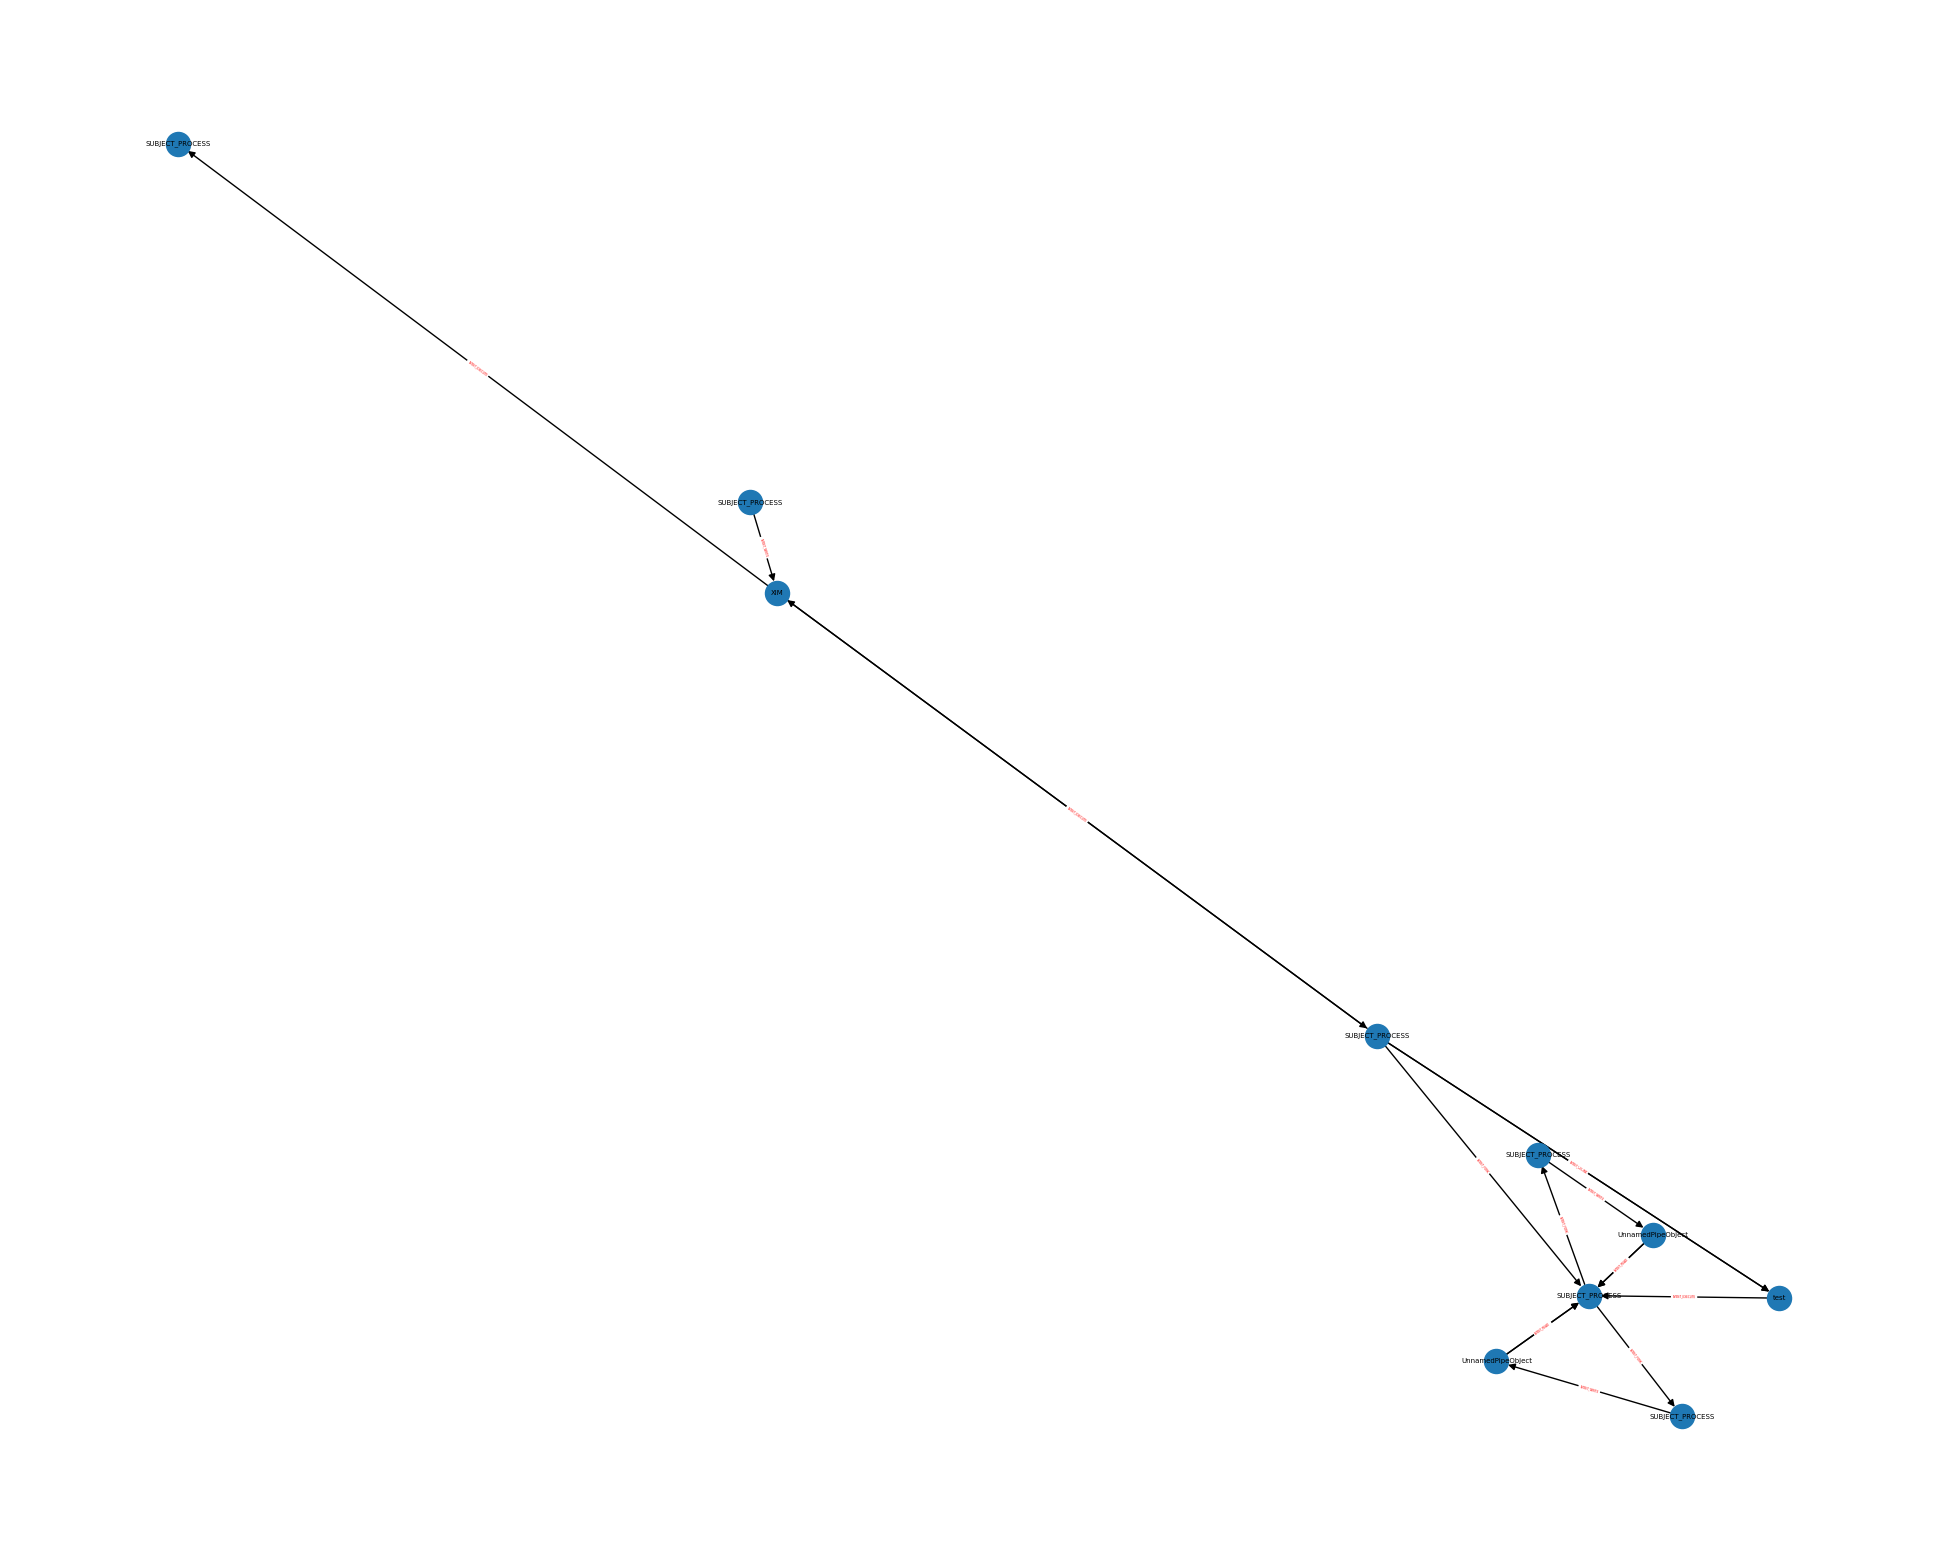

In [238]:
# len(FinalResult),FinalResult
FinalResult = Result
for node in FinalResult:
    print(node,G.nodes[node])


KeyGraph = G.subgraph(FinalResult).copy()



# 数据可视化


# import matplotlib
import matplotlib.pyplot as plt
# TestGraph = SearchGraph.subgraph(ResultNode)

# for node in KeyGraph.nodes(data=True):
#     print(str(node),KeyGraph.out_degree(node[0]))
Edgesssss=list(KeyGraph.edges(data=True))
SortedEdge = Edgesssss.sort(key = lambda x:x[2]['Sequence'])

for edge in Edgesssss:
    print(str(edge))
nodeLabels = {}
for node in KeyGraph.nodes:
    if KeyGraph.nodes[node]['path'] and KeyGraph.nodes[node]['path'] != '<unknown>':
        nodeLabels[node] = KeyGraph.nodes[node]['path']
    elif 'Cmdline' in KeyGraph.nodes[node] and KeyGraph.nodes[node]['Cmdline'] != None:
        nodeLabels[node] = KeyGraph.nodes[node]['Cmdline']
    else:
        nodeLabels[node] = KeyGraph.nodes[node]['type']
# for node in KeyGraph.nodes:
#     if KeyGraph.nodes[node]['path'] and KeyGraph.nodes[node]['path'] != '<unknown>':
#         nodeLabels[node] = KeyGraph.nodes[node]['path']
#     else:
#         nodeLabels[node] = KeyGraph.nodes[node]['type']
EdgeLabels = {}
for edge in KeyGraph.edges(data=True):
    EdgeLabels[(edge[0],edge[1])] = edge[2]['type']
nodes_to_draw = KeyGraph.nodes
edges_to_draw = KeyGraph.edges
# pos = nx.spring_layout(TestGraph,k = 100)
# pos = nx.spring_layout(TestGraph)
pos = nx.spring_layout(KeyGraph,k=0.2)
plt.figure(figsize=(25,20))
nx.draw_networkx_nodes(KeyGraph, pos,
                       nodelist=nodes_to_draw,)

# 画边
nx.draw_networkx_edges(KeyGraph, pos,
                       edgelist=edges_to_draw,)

# 画标签
nx.draw_networkx_edge_labels(KeyGraph, pos, edge_labels=EdgeLabels, font_color='red', font_size=2)
nx.draw_networkx_labels(KeyGraph, pos, font_size=5, labels=nodeLabels,font_color='black') 
# plt.savefig('Keygraph.png', dpi=600, bbox_inches='tight')
plt.axis("off")
plt.show()





# with open("D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\\DARPATC\\{x}\\1.2Test\Key_Act\\{y}.data".format(x=SubSet,y=AttckNode),'wb') as f:
#     pickle.dump(KeyGraph,f)

In [239]:
len(list(nx.weakly_connected_components(KeyGraph)))

1

In [240]:
for node in  BackConnectionNode:
    if node not in FinalResult:
        print(node)

In [241]:
def GetMark(Nodes):
    Res = 99999999
    for node in Nodes:
        # print(GetMarkSequence(G,node))
        if Res> GetMarkSequence(G,node):
            Res = GetMarkSequence(G,node)
    return Res


In [242]:

# 补充信息流活动细节（中间节点的文件读取和网络连接）,查询节点入边，考虑Sequence
# InOperation=['EVENT_READ','EVENT_EXECUTE','EVENT_MMAP','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# OutOperation=['EVENT_WRITE','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# NetObject = 'NetFlowObject'
import Sensitive

MarkSequence  = GetMark(SrcNodes) # 获取最早暴露时间作为过滤依据
print(MarkSequence)
# Indector = 10 # 超过此数值为基础信息节点
# PublicSrcType = ['.so','.dll','.so.1','.ttf','.cache']
# CaredStrs = Sensitive.SenDirLinux + Sensitive.SenInsLinux
DonotCareType = ['FILE_OBJECT_UNIX_SOCKET','UnnamedPipeObject']
RemoveNode4PublicSrc = set()
# 补充信息传播路径信息,
AddedNodes = set()
for node in FinalResult: 
    # 在补充信息时，信息输入只考虑敏感文件的读取，信息输出不作限制。取消公共信息节点移除环节
    # # 公共信息节点移除
    # if len(list(G.successors(node))) == 0: # 信息终点
    #     if len(list(G.predecessors(node))) > Indector and G.nodes[node]['type'] in PublicSrcType: # 信息源
    #         RemoveNode4PublicSrc.add(node)
    # elif len(list(G.predecessors(node))) == 0: # 信息源
    #     if len(list(G.successors(node))) > Indector and G.nodes[node]['type'] in PublicSrcType: # 信息终点
    #         RemoveNode4PublicSrc.add(node)
    # 互联网节点
    for edge in G.out_edges(node,data=True): # 在SubGraph上获取信息
        if edge[2]['Sequence'] - MarkSequence > -2: # 检验时序
            # print(1)
            if (G.nodes[edge[1]]['type'] not in DonotCareType) and DontAddNode(G,edge[1]) == False: # and NoNeedNode(G,edge[1]) == False:# 不考虑信息流方向不同的进程路径。
                print('out:',edge)
                AddedNodes.add(edge[1]) 
    # 互联网节点 + 文件节点、进程节点（此时只考虑直系父亲节点，不做追溯，因为默认其与可疑节点信息源无关）
    for edge in G.in_edges(node,data=True): # 在SubGraph上获取信息,入边只考虑敏感文件
        if edge[2]['Sequence'] - MarkSequence > -2: # 检验时序
            # print(2)
            if G.nodes[edge[0]]['type'] not in DonotCareType:
                
                try:
                    StrJudge = any(Cstr in G.nodes[edge[0]]['path'] for Cstr in Sensitive.SenDirLinux)
                except:
                    StrJudge = False
                try:
                    LineJudge = any(Cline in edge[2]['CmdLine'] for Cline in Sensitive.SenInsLinux)
                except:
                    LineJudge = False

                if G.nodes[edge[0]]['type'] == 'NetFlowObject':
                    StrJudge = True
                    
                if  (StrJudge or LineJudge)  and DontAddNode(G,edge[0]) == False:
                    print('in:',edge)
                    AddedNodes.add(edge[0])

# 根据节点提取出活动子图
ResultNode = FinalResult.union(AddedNodes) - RemoveNode4PublicSrc
print(len(ResultNode))
print(ResultNode)
TestGraph = G.subgraph(ResultNode).copy()

107720
out: ('47E61FFC-3E80-11E8-A5CB-3FA3753A265A', '47EA0B5C-3E80-11E8-A5CB-3FA3753A265A', {'type': 'EVENT_CONNECT', 'Sequence': 1320932})
out: ('47E61FFC-3E80-11E8-A5CB-3FA3753A265A', '47EA0B5C-3E80-11E8-A5CB-3FA3753A265A', {'type': 'EVENT_SENDTO', 'Sequence': 1320945})
out: ('47E61FFC-3E80-11E8-A5CB-3FA3753A265A', '47EA0B5C-3E80-11E8-A5CB-3FA3753A265A', {'type': 'EVENT_SENDTO', 'Sequence': 1322843})
out: ('47E61FFC-3E80-11E8-A5CB-3FA3753A265A', '47EB4608-3E80-11E8-A5CB-3FA3753A265A', {'type': 'EVENT_FORK', 'Sequence': 1320935})
out: ('47E61FFC-3E80-11E8-A5CB-3FA3753A265A', 'AAB27EFF-3E80-11E8-A5CB-3FA3753A265A', {'type': 'EVENT_FORK', 'Sequence': 1322832})
out: ('47E61FFC-3E80-11E8-A5CB-3FA3753A265A', '116F0CFD-3DC3-11E8-A5CA-3FA3753A265A', {'type': 'EVENT_WRITE', 'Sequence': 1322900})
in: ('51110606-D232-9652-B2D2-3A7242968F8A', '47E61FFC-3E80-11E8-A5CB-3FA3753A265A', {'type': 'EVENT_READ', 'Sequence': 1320923})
in: ('47EA0B5C-3E80-11E8-A5CB-3FA3753A265A', '47E61FFC-3E80-11E8-A5CB

In [243]:
# 增加一个公共信息源移除机制，一些被不同进程普遍使用的，只读不写且非敏感文件的公共文件。只读不写代表与此次外部信息流无关


('E5F1BC5B-052D-3F5F-AD05-928A8F3FF746', {'type': 'FILE_OBJECT_FILE', 'path': 'netlog', 'localAddress': None, 'remoteAddress': None}) 0
('4DA445A7-56DB-D353-9B56-AD9CD3D373D6', {'type': 'FILE_OBJECT_FILE', 'path': 'main', 'localAddress': None, 'remoteAddress': None}) 0
('74D78344-4A18-265B-984A-8D22BB26DDCF', {'type': 'FILE_OBJECT_FILE', 'path': 'minions', 'localAddress': None, 'remoteAddress': None}) 0
('47EB4608-3E80-11E8-A5CB-3FA3753A265A', {'type': 'SUBJECT_PROCESS', 'parentSubject': '47E61FFC-3E80-11E8-A5CB-3FA3753A265A', 'Cmdline': None, 'path': None, 'name': None}) 1
('CC47847C-4B33-915B-B34B-79E64B9162AE', {'type': 'FILE_OBJECT_FILE', 'path': '/var/log/nginx-error.log', 'localAddress': None, 'remoteAddress': None}) 0
('9A717117-65ED-675C-AD65-38102C67C832', {'type': 'FILE_OBJECT_FILE', 'path': '/etc/login.conf', 'localAddress': None, 'remoteAddress': None}) 2
('E2731C3F-FB39-5CAD-8E8C-005C09AB5F2E', {'type': 'UnnamedPipeObject', 'path': '<unknown>', 'localAddress': None, 'remot

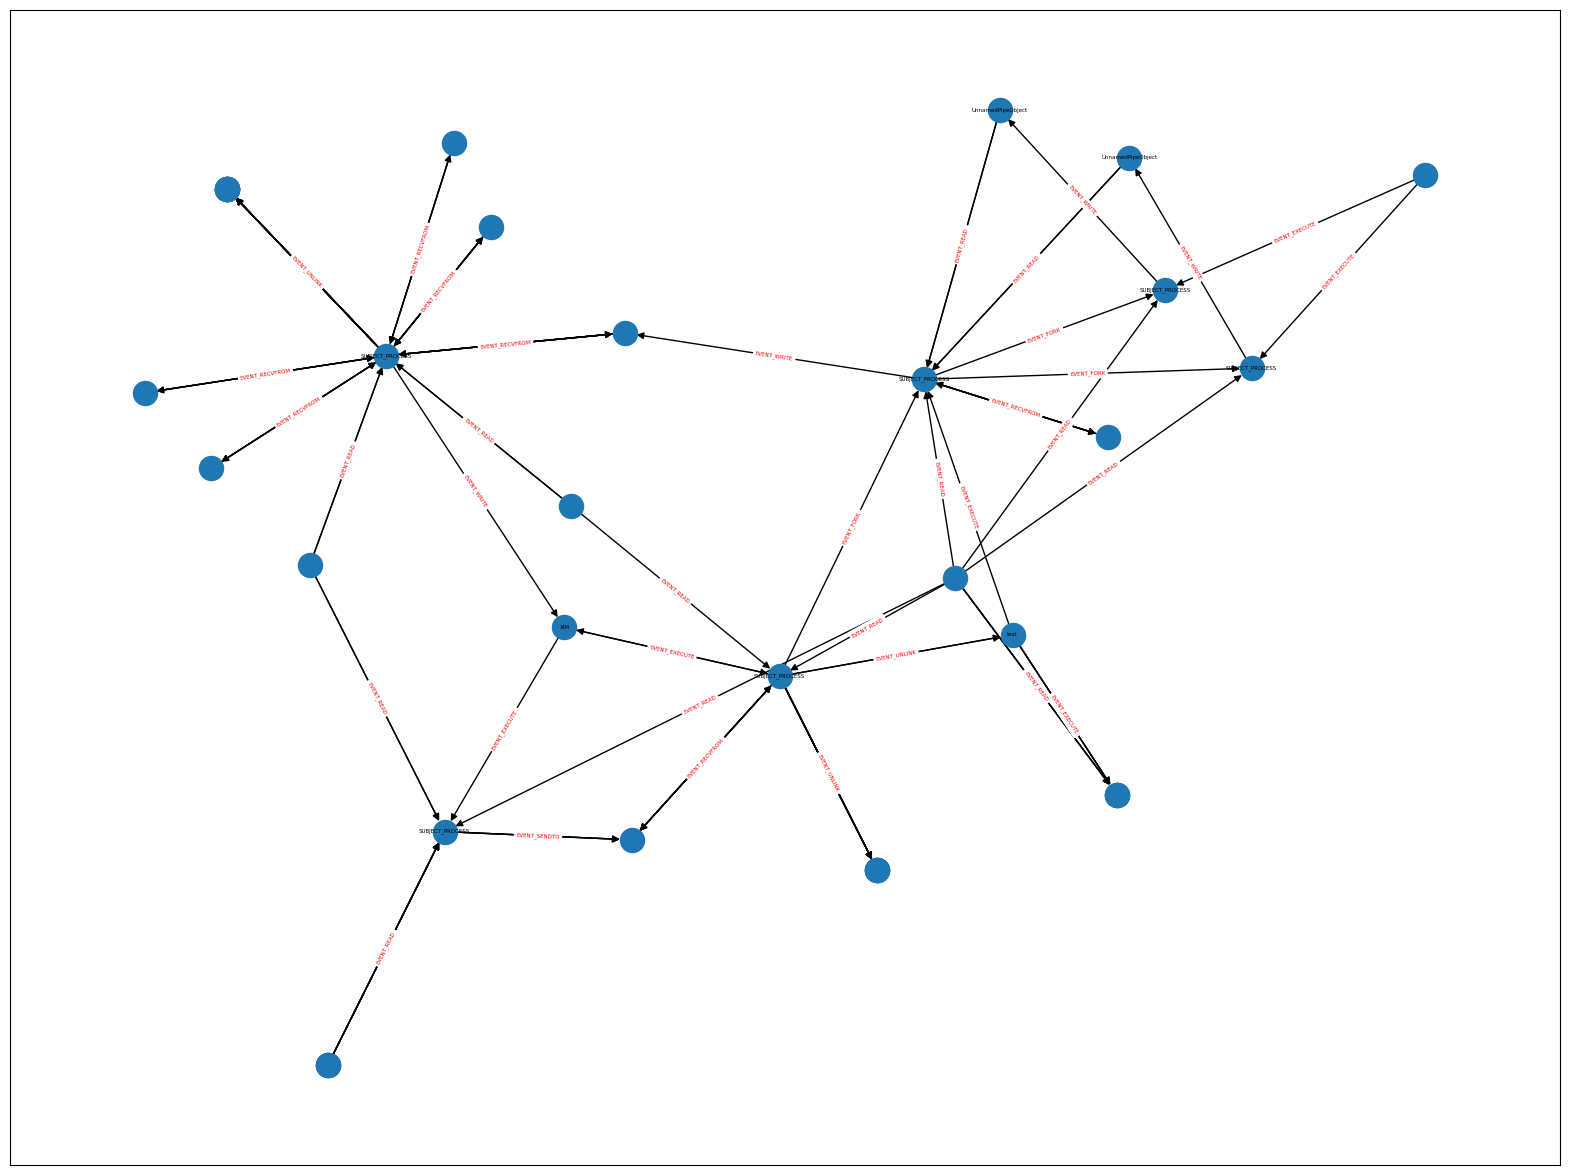

In [244]:
# 数据可视化


# import matplotlib
import matplotlib.pyplot as plt
# TestGraph = SearchGraph.subgraph(ResultNode)

for node in TestGraph.nodes(data=True):
    print(str(node),TestGraph.out_degree(node[0]))
Edgesssss=list(TestGraph.edges(data=True))
SortedEdge = Edgesssss.sort(key = lambda x:x[2]['Sequence'])

for edge in Edgesssss:
    print(str(edge))
nodeLabels = {}
for node in KeyGraph.nodes:
    if KeyGraph.nodes[node]['path'] and KeyGraph.nodes[node]['path'] != '<unknown>':
        nodeLabels[node] = KeyGraph.nodes[node]['path']
    elif 'Cmdline' in KeyGraph.nodes[node] and KeyGraph.nodes[node]['Cmdline'] != None:
        nodeLabels[node] = KeyGraph.nodes[node]['Cmdline']
    else:
        nodeLabels[node] = KeyGraph.nodes[node]['type']
# for node in TestGraph.nodes:
#     if TestGraph.nodes[node]['path'] and TestGraph.nodes[node]['path'] != '<unknown>':
#         nodeLabels[node] = TestGraph.nodes[node]['path']
#     else:
#         nodeLabels[node] = TestGraph.nodes[node]['type']
EdgeLabels = {}
for edge in TestGraph.edges(data=True):
    EdgeLabels[(edge[0],edge[1])] = edge[2]['type']
nodes_to_draw = TestGraph.nodes
edges_to_draw = TestGraph.edges
# pos = nx.spring_layout(TestGraph,k = 100)
# pos = nx.spring_layout(TestGraph)
pos = nx.kamada_kawai_layout(TestGraph)
plt.figure(figsize=(20,15))
nx.draw_networkx_nodes(TestGraph, pos,
                       nodelist=nodes_to_draw,)

# 画边
nx.draw_networkx_edges(TestGraph, pos,
                       edgelist=edges_to_draw,)

# 画标签
nx.draw_networkx_edge_labels(TestGraph, pos, edge_labels=EdgeLabels, font_color='red', font_size=4)
nx.draw_networkx_labels(TestGraph, pos, font_size=4, labels=nodeLabels,font_color='black') 
# plt.axis("off")
# plt.show()
plt.savefig('graph.png', dpi=600, bbox_inches='tight')





In [245]:

# with open("D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\\DARPATC\\{x}\\1.2Test\Sus_Act\\{y}.data".format(x=SubSet,y=AttckNode),'wb') as f:
#     pickle.dump(TestGraph,f)

In [ ]:
Thunder, Firefox

NameError: name 'Thunder' is not defined

: 

In [ ]:


a = 30546
b = 1729399
xxx = 9
c = int((b - a)/xxx)

FirRecod = []
ThuRecod = []

count = 0
for i in range(xxx):
    print(a + i*c)
    print(a + (i+1)*c)
    Label = False
    for key in Firefox:
        if a+i*c <= Firefox[key] < a+(i+1)*c and key not in FirRecod:
            FirRecod.append(key)
            if Label == False:
                count += 1
                Label = True
print('Result:',count/xxx)

count = 0
for i in range(xxx):
    # print(a + i*c)
    # print(a + (i+1)*c)
    Label = False
    for key in Thunder:
        if (a+i*c) <= Thunder[key] < (a+(i+1)*c) and key not in ThuRecod:
            ThuRecod.append(key)
            if Label == False:
                count += 1
                Label = True
print('Result:',count/xxx)




30546
219307
219307
408068
408068
596829
596829
785590
785590
974351
974351
1163112
1163112
1351873
1351873
1540634
1540634
1729395
Result: 0.0
Result: 0.0
